## imports and helper function

In [1]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from cmdstanpy import CmdStanModel
import cmdstanpy
import numpy as np
from scipy.stats import invgamma
from scipy.stats import norm
from scipy.special import softmax
from gptools.stan import get_include

import pandas as pd
from glob import glob
from nteprsm import utils 
from cmdstanpy import stanfit
from settings import ROOT_DIR
import plotly.express as px
import utils as notebook_utils
# use customize plotly template
notebook_utils.set_custom_template()

import pickle
import seaborn as sns
import plotly.subplots as sp
from matplotlib import colors as mcolors

import arviz as az
from scipy.interpolate import CubicSpline


from scipy.special import iv as modified_bessel_first_kind
from scipy.special import iv  # modified Bessel function of the first kind
import difflib

/tmp/ipykernel_526/1179652658.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
NTEP_COLOR_SCALE = ["#8c510a","#bf812d","#dfc27d","#f6e8c3","#c7e9c0","#74c476","#41ab5d","#238b45","#00441b"]
def map_name2code(datahandler, column_name, code_column_name, invert=False):
    """
    Retrieves a dictionary mapping names to codes from specified columns.

    Args:
        column_name(str): The name of the column containing the names(
        e.g., 'ENTRY_NAME', 'RATER').
        code_column_name(str): The name of the column containing the codes
        (e.g., 'ENTRY_NAME_CODE', 'RATER_CODE').
        invert(bool): If True, returns a dictionary mapping codes to names.

    Returns:
        dict: Depending on 'invert', returns either a dict of {name: code}
        or {code: name}.
    """
    name2code = dict(datahandler.model_data.groupby(column_name)[code_column_name].first())

def rsm_probability(y, theta, thresholds):
    """
    Calculates the probability of a given class label in the model.

    Args:
    y (int): The class label for which the probability is calculated.
    theta (np.ndarray): An array of model parameters.
    tau (np.ndarry): The threshold parameters for the model.

    Returns:
    float: The probability of the given class label.

    """
    unsummed = np.concatenate(([0], theta - thresholds))
    probs = softmax(np.cumsum(unsummed))
    return probs[y]

def rsm_probability_vector(theta, thresholds):
    """
    Calculates the probability of set of class labels in given model

    Args:
    theta (np.ndarray): An array of model parameters.
    tau (np.ndarry): The threshold parameters for the model.

    Returns:
    np.ndarray: Array probability of given class label.
    """
    unsummed = np.concatenate(([0], theta - thresholds))
    probs = softmax(np.cumsum(unsummed))
    return probs
    
def plot_rater_characteristic_curve(
        betas,
        min_theta=-6,
        max_theta=6,
        resolution=500,
        colors=px.colors.diverging.Spectral,
        dimensions=None,
    ) -> go.Figure:
        """
        Plot the characteristic curves for raters based on the fitted Stan model.

        Args:
            rater_id (int, optional): The rater ID to plot. If None, all raters
                will be plotted. Defaults to None.
            dimensions (tuple, optional): Dimensions of the plot as (width, height).

        Returns:
            A Plotly figure object containing the plotted characteristic curves.
        """
        betas_with_bounds = np.concatenate(([min_theta], betas, [max_theta]))
        x = np.linspace(min_theta, max_theta, int((max_theta - min_theta) * resolution))
        num_categories = len(betas) + 1
        fig = go.Figure()
        fig.update_layout(
            template="ggplot2",
            xaxis_title="Turf Quality on Latent Scale",
            yaxis_title="Probability",
            legend=dict(x=1.02, y=1),
        )
        for i in range(num_categories):
            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=[rsm_probability(i, theta, betas) for theta in x],
                    line=dict(width=2, color=colors[i]),
                    name=str(i + 1),
                )
            )
            fig.add_shape(
                type="rect",
                x0=betas_with_bounds[i],
                x1=betas_with_bounds[i + 1],
                y0=1.02,
                y1=1.1,
                fillcolor=colors[i],
            )
            if i != num_categories - 1:
                fig.add_shape(
                    type="line",
                    x0=betas[i],
                    x1=betas[i],
                    y0=0,
                    y1=1,
                    line=dict(color=colors[i], dash="dot"),
                )
        if dimensions:
            fig.update_layout(width=dimensions[0], height=dimensions[1])
        return fig

def hex_to_rgba(hex_color, alpha=0.2):
    """Convert a HEX color (e.g., '#1f77b4') to an RGBA string with transparency."""
    rgb = mcolors.hex2color(hex_color)  # Convert hex to RGB (normalized 0-1)
    return f'rgba({int(rgb[0]*255)}, {int(rgb[1]*255)}, {int(rgb[2]*255)}, {alpha})'

def dms_to_decimal(coord):
    # Split the coordinate into components
    parts = coord.split()
    degrees = int(parts[0][:-1])  # Remove the "°"
    minutes = int(parts[1][:-1])  # Remove the "'"
    direction = parts[2]          # Direction (N, S, E, W)
    
    # Convert to decimal degrees
    decimal = degrees + (minutes / 60)
    
    # Adjust for direction
    if direction in ['S', 'W']:
        decimal = -decimal
    
    return decimal

In [3]:
def smart_lookup(word, wordlist, cutoff=0):
    # Try direct hit first
    if word in wordlist:
        return word
        
    # Try fuzzy matching
    matches = difflib.get_close_matches(word, wordlist, n=1, cutoff=cutoff)
    if matches:
        return matches[0]
        
    # Try substring (partial) matches
    for target in wordlist:
        if word.lower() in target.lower():
            return target
    raise KeyError(f"No close match found for '{word}'.")
    
def diagSPD_periodic(alpha, rho, M):
    a = 1 / rho**2
    n = np.arange(1, M+1)
    log_bessel = np.log(iv(n, a))
    q = np.exp(np.log(alpha) + 0.5 * (np.log(2) - a + log_bessel))
    return np.concatenate([q, q])  # append_row in Stan

def PHI_periodic(x, M, w0):
    """
    x: array of shape [N] (locations you want to evaluate at)
    M: number of basis functions
    w0: frequency (usually 2*pi / period)
    Returns: matrix of shape [N, 2*M]
    """
    x = np.asarray(x)
    N = len(x)
    k = np.arange(1, M+1)
    mw0x = np.outer(x, w0*k)  # shape (N, M)
    return np.hstack([np.cos(mw0x), np.sin(mw0x)])  # shape (N, 2*M)

def reconstruct_pred_time_1_sample(sigma_f, lengthscale_f, beta_f, intercept_f, M_f, pred_N, sd_time, mean_time):
    # x_pred: points where you want to evaluate the GP
    x_pred = np.arange(1, pred_N+1) / pred_N
    x_pred = (x_pred - mean_time)/sd_time

    w0 = 2 * np.pi*sd_time  # period = 1/sd_time
    PHI_f = PHI_periodic(x_pred, M_f, w0)  # shape [len(x_pred), 2*M_f]
    diagSPD_f = diagSPD_periodic(sigma_f, lengthscale_f, M_f)  # shape [2*M_f]
    
    # GP curve at x_pred:
    gp_curve = intercept_f + PHI_f @ (diagSPD_f * beta_f)  # [len(x_pred)]
    return gp_curve

def reconstruct_pred_time_samples(entry_code, loc_code, fit, rating_event_times, pred_N = 50, max_samples =6000):
    if loc_code == None or loc_code <= 0:
        M_f = fit.beta_f.shape[-1]//2
        beta_f_samples = fit.beta_f[:, entry_code - 1, :]
        intercept_f_samples = fit.intercept_f[:, entry_code - 1]
    else:
        M_f = fit.beta_f.shape[-2]//2
        beta_f_samples = fit.beta_f[:,entry_code-1,:,loc_code - 1]
        intercept_f_samples = fit.intercept_f[:, loc_code - 1, entry_code - 1]
    sigma_f_samples = fit.sigma_f
    lengthscale_f_samples = fit.lengthscale_f

    reconstructed_curves = []

    sd_time = np.std(rating_event_times, ddof=1)
    mean_time = np.mean(rating_event_times)
    
    for i in range(min(beta_f_samples.shape[0], max_samples)):
        reconstructed_curves.append(reconstruct_pred_time_1_sample(sigma_f_samples[i],
                                                                   lengthscale_f_samples[i], 
                                                                   beta_f_samples[i], 
                                                                   intercept_f_samples[i],
                                                                   M_f, 
                                                                   pred_N,
                                                                   sd_time,
                                                                   mean_time)
                                   )

    return np.array(reconstructed_curves)

def get_rating_event_times_thetas(df, fit, loc_code, entry_code):
    filt_df =  df[df['test_loc_code'] == loc_code]
    rating_event_data = filt_df[['adj_time_of_year','rating_event_code']].drop_duplicates()
    rating_event_times = rating_event_data['adj_time_of_year']
    data_points_rating_events = rating_event_data['rating_event_code']        
    data_points_mean = fit.time_effect[:,loc_code-1,:,:].mean(axis=0)
    rating_event_thetas = [data_points_mean[entry_code-1][j-1] for j in data_points_rating_events]

    return rating_event_times, rating_event_thetas

def plot_seasonality_curve(fig, rating_event_times, rating_event_thetas, pred_time_samples, ci, color, trace_name):
    legend_group = trace_name 
    samples = pred_time_samples

    pred_N = samples.shape[1]

    # Compute statistics
    time_points = (100/pred_N)*np.arange(pred_N)  # Time indices
    mean_values = np.mean(samples, axis=0)  # Mean over samples
    lower_bound = np.percentile(samples, 100 * (1 - ci) / 2, axis=0)  # 2.5th percentile
    upper_bound = np.percentile(samples, 100 * (ci + (1 - ci) / 2), axis=0)  # 97.5th percentile

    # wraparound adjustment
    mean_values =  [mean_values[-1]]+ list(mean_values[:-1])
    lower_bound = np.array([lower_bound[-1]] + list(lower_bound[:-1]))
    upper_bound = np.array([upper_bound[-1]] + list(upper_bound[:-1]))
    
    # Add data point
    fig.add_trace(go.Scatter(
        x=rating_event_times * 100, y=rating_event_thetas,
        mode='markers',
        marker=dict(
            symbol='circle',  # Set the marker shape to "X"
            color=color,  # Keep the color
            size=10  # Optionally, set the size of the marker
        ),
        name=trace_name,
        legendgroup=legend_group,
        showlegend=False,
    ))

    # Add mean line
    fig.add_trace(go.Scatter(
        x=time_points, y=mean_values,
        mode='lines',
        line=dict(color=color, width=2),
        name=trace_name,
        legendgroup=legend_group,
    ))

    # Add 95% Credible Interval (Shaded Region)
    fig.add_trace(go.Scatter(
        x=time_points.tolist() + time_points[::-1].tolist(),
        y=upper_bound.tolist() + lower_bound[::-1].tolist(),
        fill='toself',
        fillcolor=hex_to_rgba(color, alpha=0.2)  ,
        line=dict(color='rgba(255,255,255,0)'),
        name=trace_name,
        legendgroup=legend_group,  # Grouping
        showlegend=False,
    ))
    return fig

def set_annual_axes(fig, title, legend_title = 'Entries'):
    # Compute correct tick positions based on actual day of the year
    days_in_month = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])  # Non-leap year
    cumulative_days = np.cumsum(days_in_month)+1  # Cumulative sum to get end of each month
    month_positions = 100*cumulative_days / 365  # Normalize to range 0-100
    month_positions[0] += 0.8
    
    #month_positions = np.insert(month_positions, 0, 0)
    # Generate month labels
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    fig.update_layout(
        xaxis=dict(
            tickvals=month_positions,  # Correctly spaced tick positions
            ticktext=month_labels,  # Month names
            title="Time of Year"
        ),
        yaxis_title="Seasonality (Latent Scale)",
        title=title,
        template="ggplot2",
        legend=dict(title=legend_title)
    )

    return fig

def plot_entries_at_loc(entry_strs,
                        df,
                        fit,
                        entry_name2code,
                        testloc_code2name,
                        loc_code = 1,
                        colors =  ['slateblue','orange','seagreen', 'indianred', 'dodgerblue', 'limegreen', 'violet', 'gold', 'aquamarine', 'crimson'],
                        ci = 0.95,
                        pred_N = 100):
    """
    Arguments:
    entry_strs : array-like of strings - the entries that the user wants to see, fuzzy matching will determine closest match
    df         : dataframe - df that was used to generate the stan_data fed into the SPATIAL COREGIONALIZATION stan model
    fit        : posterior fit samples generated by the SPATIAL COREGIONALIZATION model
    entry_name2code   : dictionary converting entry_name (string) -> entry_code (int)
    testloc_code2name : dictionary converting loc_code (int) -> location_name (string)
    loc_code   : test_loc_code of the location to plot the seasonality curves on
    colors     : array-like of colors, colors[i] will be used for entries[i]
    ci         : float from 0-1, size of credible interval
    pred_N     : resolution/number of samples of reconstructed posterior curves
    """
    fig = go.Figure()

    entries = []

    remaining_entries = list(entry_name2code.keys())
    for entry_str in entry_strs:
        entry_name = smart_lookup(entry_str, remaining_entries)
        remaining_entries.remove(entry_name)
        entries.append(entry_name2code[entry_name])
        if entry_str != entry_name:
            print(f"Could not find entry {entry_str} in list of entries, showing results for {entry_name} instead")

    all_rating_event_times = df[['rating_event_code','adj_time_of_year']].drop_duplicates()['adj_time_of_year']
    for i, entry in enumerate(entries):
        rating_event_times, rating_event_thetas = get_rating_event_times_thetas(df, fit, loc_code, entry)
        #rating_event_thetas = [data_points_mean[entry-1][j-1] for j in data_points_rating_events]
        entry_name = entry_code2name[entry]
        pred_time_samples = reconstruct_pred_time_samples(entry,
                                                          loc_code,
                                                          fit,
                                                          all_rating_event_times,
                                                          pred_N=pred_N
                                                         )
        
        plot_seasonality_curve(fig,
                               rating_event_times,
                               rating_event_thetas,
                               pred_time_samples,
                               ci,
                               colors[i],
                               entry_name)
        
    title=f"Turfgrass Seasonality at {testloc_code2name[loc_code]}, {ci} credible interval"
    set_annual_axes(fig, title, legend_title = 'Entries')
    return fig

# Define colors for each entry
def compare_seasonality_curve_by_locs(entry_str,
                        df,
                        fit,
                        entry_name2code,
                        testloc_code2name,
                        loc_codes = [1,2,3,4,5,6,7],
                        colors =  ['slateblue','orange','seagreen', 'indianred', 'dodgerblue', 'limegreen', 'violet', 'gold', 'aquamarine', 'crimson'],
                        ci = 0.95,
                        pred_N = 100):
    """
    Arguments:
    entry_strs : string - the entry that the user wants to see, fuzzy matching will determine closest match
    df         : dataframe - df that was used to generate the stan_data fed into the SPATIAL COREGIONALIZATION stan model
    fit        : posterior fit samples generated by the SPATIAL COREGIONALIZATION model
    entry_name2code   : dictionary converting entry_name (string) -> entry_code (int)
    testloc_code2name : dictionary converting loc_code (int) -> location_name (string)
    loc_codes  : array-like of ints, corresponding
    colors     : array-like of colors, colors[i] will be used for loc_codes[i]
    ci         : float from 0-1, size of credible interval
    pred_N     : resolution/number of samples of reconstructed posterior curves
    """

    fig = go.Figure()
    all_rating_event_times = df[['rating_event_code','adj_time_of_year']].drop_duplicates()['adj_time_of_year']

    entry_name = smart_lookup(entry_str, entry_name2code.keys())
    if entry_str != entry_name:
        print(f"Could not find entry {entry_str} in list of entries, showing results for {entry_name} instead")
    entry = entry_name2code[entry_name]

    for i, loc_code in enumerate(loc_codes):
        rating_event_times, rating_event_thetas = get_rating_event_times_thetas(df, fit, loc_code, entry)
        loc_name = testloc_code2name[loc_code]
        pred_time_samples = reconstruct_pred_time_samples(entry,
                                                          loc_code,
                                                          fit,
                                                          all_rating_event_times,
                                                          pred_N=pred_N
                                                          )
        plot_seasonality_curve(fig,
                               rating_event_times,
                               rating_event_thetas,
                               pred_time_samples,
                               ci,
                               colors[i],
                               loc_name)
    
    # Compute correct tick positions based on actual day of the year
    title=f"Turfgrass Seasonality for {entry_code2name[entry]}, {ci} credible interval"
    set_annual_axes(fig, title, legend_title = 'Trial Locations')
    return fig

def compare_seasonality_with_annual_model(entry_str,
                                          df,
                                          fit_geo,
                                          fit_as,
                                          geo_entry_name2code,
                                          as_entry_name2code,
                                          loc_code = 1,
                                          colors = ["red", "#4fa3d1"],
                                          ci = 0.95,
                                          pred_N = 100):

    """
    Arguments:
    entry_str  : string - the entry (string) that the user wants to see, fuzzy matching will determine closest match
    df         : dataframe - df that was used to generate the stan_data fed into the SPATIAL COREGIONALIZATION stan model
    fit_geo    : posterior fit samples generated by the SPATIAL COREGIONALIZATION model
    fit_as     : posterior fit samples generated by the ANNUAL SEASONALITY (independent location) model
    loc_code   : test_loc_code of the location to compare. ANNUAL SEASONALITY must be fit on this location
    colors     : array-like of colors of at least len(2). colors[0] will be used for SPATIAL COREGIONALIZATION, colors[1] for ANNUAL SEASONALITY
    ci         : float from 0-1, size of credible interval
    pred_N     : resolution/number of samples of reconstructed posterior curves
    """
    
    fig = go.Figure()
    fit = fit_geo

    entry_name = smart_lookup(entry_str, geo_entry_name2code.keys())
    if entry_str != entry_name:
        print(f"Could not find entry {entry_str} in list of entries, showing results for {entry_name} instead")
    
    entry_geo = geo_entry_name2code[entry_name]
    
    # time_effect_data_points
    all_rating_event_times = df[['rating_event_code','adj_time_of_year']].drop_duplicates()['adj_time_of_year']
    rating_event_times, rating_event_thetas = get_rating_event_times_thetas(df, fit, loc_code, entry_geo)
    
    pred_time_samples = reconstruct_pred_time_samples(entry_geo,
                                                      loc_code,
                                                      fit,
                                                      all_rating_event_times,
                                                      pred_N=pred_N
                                                     )
    plot_seasonality_curve(fig,
                           rating_event_times,
                           rating_event_thetas,
                           pred_time_samples,
                           ci,
                           colors[0],
                           'Spatial coregionalization model')
    
    # Plot original annual seasonality without geographical
    entry_as = as_entry_name2code[entry_name]
    data_points = fit_as.time_effect  
    pred_time_samples = reconstruct_pred_time_samples(entry_as,
                                                      -1,
                                                      fit_as,
                                                      rating_event_times,
                                                      pred_N = pred_N
                                                     )

    plot_seasonality_curve(fig,
                           rating_event_times,
                           rating_event_thetas = fit_as.time_effect.mean(axis=0)[entry_as-1],
                           pred_time_samples = pred_time_samples,
                           ci = ci,
                           color = colors[1],
                           trace_name='Independent locations model')
    
    title = f"Turfgrass Seasonality for {entry_name}, {ci} credible interval"
    set_annual_axes(fig, title, legend_title = 'Models')
    
    return fig

## get data

In [4]:
dfs = []
plt_layouts = []
rowcolswaps = []

files = ['quality_in1', 'quality_mi1', 'quality_mn1', 'quality_nj2', 'quality_ok1', 'quality_ut1', 'quality_nc1']
#files = ['quality_mi1', 'quality_mn1', 'quality_nj2', 'quality_ok1', ]
loc_counter = 0

for file in files:
    df = pd.read_csv(f'data/raw/{file}.csv')
    try:
        ## create adj_time_of_year columns
        df.columns = [col.lower() for col in df.columns]
        df['date']=pd.to_datetime(df["date"], format='%m/%d/%y')
        df["adj_day_of_year"] = df.date.dt.day_of_year - (
            df.date.dt.is_leap_year * df.date.dt.day_of_year >= 60
        )
        df["adj_time_of_year"] = df.adj_day_of_year / 365
        
        ## quality_ok1 uses ploc_code
        if 'ploc_code' in df.columns:
            df['plt_id'] = df['ploc_code']

        if df['col'].max() > df['row'].max():
            rowcolswaps.append(1)
            temp = df['col'].values
            df['col'] = df['row']
            df['row'] = temp
        else:
            rowcolswaps.append(0)
        df['plt_id_code'] = pd.Categorical(df["plt_id"]).codes + 1
        df["entry_cumcount"] = df.groupby("entry_name").cumcount() + 1
        df["file"] = file
        df["trial_location_code"] = loc_counter
        loc_counter +=1
        dfs.append(df)

        # handle plot_data
        plt_data = df[['plt_id_code', 'row', 'col']].drop_duplicates().sort_values('plt_id_code')
        assert len(plt_data) == int(plt_data.plt_id_code.nunique())
        plt_layouts.append(plt_data)
        
    except Exception as e:
        print(f"Error processing {file}")
        print(f"Error message: {e}")
        print(f"df columns: {df.columns}")

In [5]:
df = pd.concat(dfs, axis=0)

df = df.assign(
    entry_name_code=pd.Categorical(df["entry_name"]).codes + 1,
    rater_code=pd.Categorical(df["rater"]).codes + 1,
    rating_event_code=pd.Categorical(df["rating_event"]).codes + 1,
    test_loc_code=pd.Categorical(df["test_loc"]).codes + 1,
)

df[['entry_name','test_loc']].drop_duplicates().sort_values('entry_name')

,entry_name,test_loc
576,A06-8,"Adelphia, NJ"
227,A06-8,"Raleigh, NC"
130,A06-8,"Stillwater, OK"
248,A06-8,"East Lansing, MI"
130,A06-8,"West Lafayette, IN"
...,...,...
139,Yellowstone (A12-7),"West Lafayette, IN"
252,Yellowstone (A12-7),"Adelphia, NJ"
3,Yellowstone (A12-7),"East Lansing, MI"
111,Yellowstone (A12-7),"Logan, UT"


In [6]:
df.groupby('test_loc')['test_loc'].count()

test_loc
Adelphia, NJ           9612
East Lansing, MI       6141
Logan, UT              6675
Raleigh, NC           10128
St. Paul, MN           6141
Stillwater, OK         8010
West Lafayette, IN     8010
Name: test_loc, dtype: int64

In [7]:
len(df)

54717

In [8]:
entry_name2code = dict(df.groupby('entry_name')['entry_name_code'].first())
entry_code2name = dict(df.groupby('entry_name_code')['entry_name'].first())

testloc_name2code = dict(df.groupby('test_loc')['test_loc_code'].first())
testloc_code2name =  dict(df.groupby('test_loc_code')['test_loc'].first())

In [9]:
rowcolswaps

[0, 0, 1, 0, 0, 0, 0]

## Geographical locations

In [10]:
df[['test_loc', 'test_loc_code']].drop_duplicates()

,test_loc,test_loc_code
0,"West Lafayette, IN",7
0,"East Lansing, MI",2
0,"St. Paul, MN",5
0,"Adelphia, NJ",1
0,"Stillwater, OK",6
0,"Logan, UT",3
0,"Raleigh, NC",4


In [11]:
locs = df['test_loc'].unique()
locs

array(['West Lafayette, IN', 'East Lansing, MI', 'St. Paul, MN',
       'Adelphia, NJ', 'Stillwater, OK', 'Logan, UT', 'Raleigh, NC'],
      dtype=object)

In [12]:
#test_loc_to_code = df[['test_loc', 'test_loc_code']].drop_duplicates().set_index('test_loc')['test_loc_code'].to_dict()
#code_to_test_loc = df[['test_loc', 'test_loc_code']].drop_duplicates().set_index('test_loc_code')['test_loc'].to_dict()

coordinates = {
    'West Lafayette, IN': ("040º 26' N", "086° 55' W"),
    'East Lansing, MI': ("042º 42' N", "084° 28' W"),
    'St. Paul, MN': ("44º 53' N", "93° 13' W"),
    'Raleigh, NC': ("035º 52' N", "078° 47' W"),
    'Adelphia, NJ': ("040º 29' N", "074° 27' W"),
    'Stillwater, OK': ("038º 02' N", "084° 36' W"),
    'Logan, UT': ("041º 47' N", "111° 51' W")
}

lats = []
lons = []

for i in range(len(locs)):
    loc = testloc_code2name[i+1]
    lat, lon = coordinates[loc]
    decimal_lat = dms_to_decimal(lat)
    decimal_lon = dms_to_decimal(lon)
    lats.append(decimal_lat)
    lons.append(decimal_lon)

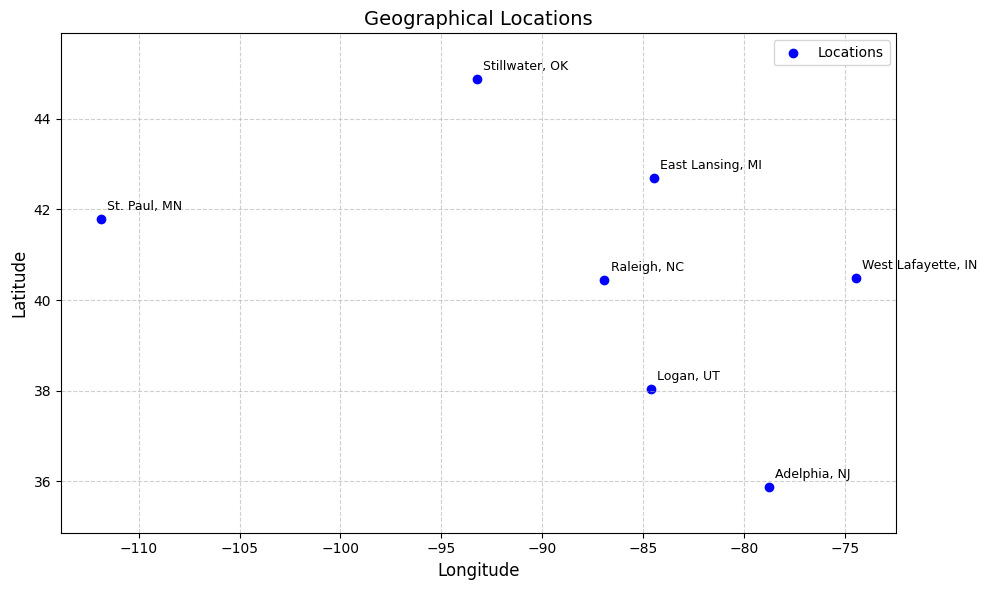

In [13]:
# Data
locations = df['test_loc'].unique()
plt.figure(figsize=(10, 6))
plt.scatter(lons, lats, c='blue', marker='o', label='Locations')

# Annotate points
for i, location in enumerate(locs):
    plt.text(lons[i] + 0.3, lats[i] + 0.2, location, fontsize=9)  # slight offset

# Add axis labels and title
plt.title('Geographical Locations', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

# Add margins to avoid overlap
lon_min, lon_max = min(lons), max(lons)
lat_min, lat_max = min(lats), max(lats)
plt.xlim(lon_min - 2, lon_max + 2)   # Add margin to x-axis
plt.ylim(lat_min - 1, lat_max + 1)   # Add margin to y-axis

plt.tight_layout()
plt.show()

### Model sampling

In [14]:
target = 'quality'
padding = 1
pred_N = 1
M_f = 8
iter_warmpup = 350
iter_sampling = 500
num_chains = 4

In [15]:
target = 'quality'
padding = 1
pred_N = 1
M_f = 8

row_list = [plt_layouts[i].sort_values('plt_id_code')['row'].values for i in range(df['test_loc_code'].nunique())]
col_list = [plt_layouts[i].sort_values('plt_id_code')['col'].values for i in range(df['test_loc_code'].nunique())]

stan_data = {
    "N": len(df[target]),
    "L": df['test_loc_code'].nunique(),
    "num_categories": int(df[target].nunique()),
    "y": (df['quality'] - df[target].min()).values,
    "num_raters": int(df.rater.nunique()),
    "num_entries": int(df.entry_name.nunique()),
    "trial_loc": df['test_loc_code'],

    # trial layouts
    "num_plots": df.groupby('test_loc_code')['plt_id_code'].max().values,
    'total_num_plots':np.sum(df.groupby('test_loc_code')['plt_id_code'].max().values),
    "num_rows": df.groupby('test_loc_code')['row'].max().values,
    "num_cols": df.groupby('test_loc_code')['col'].max().values,
    "plot_row": np.concatenate(row_list),
    "plot_col": np.concatenate(col_list),
    "rater_id": df.rater_code.values,
    "entry_id": df.entry_name_code.values,
    "plot_id": df.plt_id_code.values,

    # geographical data
    "lats":lats,
    "lons":lons,

    ## time
    "num_rating_events": int(df['rating_event_code'].nunique()),
    "rating_event_codes": df['rating_event_code'],
    "time": df[['rating_event_code','adj_time_of_year']].drop_duplicates().sort_values('rating_event_code').set_index('rating_event_code').values.reshape(-1),

    # maps rating event -> temperature
    ## predictions
    'pred_N':pred_N,

    ## approximation params
    "padding": padding,
    "M_f":M_f,
}


In [15]:
# load model configuration
config_file = ROOT_DIR/"config/nteprsm_njkbg07.yml"
config = utils.load_config(config_file)
config["sampling"]['save_warmup'] = False
config["sampling"]["iter_sampling"] = iter_sampling
config["sampling"]["iter_warmup"] = iter_warmpup
config["sampling"]["parallel_chains"] = num_chains
config

{'data_path': 'data/raw/quality_nj2.csv',
 'stan_file': 'models/nteprsm_turf_annual_seasonality.stan',
 'stan_additional_data': {'M_f': 8, 'pred_N': 100, 'padding': 5},
 'sampling': {'parallel_chains': 4,
  'seed': 1,
  'show_progress': True,
  'adapt_delta': 0.99,
  'max_treedepth': 15,
  'refresh': 20,
  'iter_warmup': 350,
  'iter_sampling': 500,
  'save_warmup': False,
  'output_dir': 'data/model_output',
  'time_fmt': '%Y%m%d',
  'show_console': True}}

In [16]:
file_name = 'geographical_model_hierarchical_rater_nopred'
nteprsm = CmdStanModel(
    stan_file=f'models/{file_name}.stan',
    stanc_options={"include-paths": get_include()},
)
fit = nteprsm.sample(data=stan_data, **config["sampling"])

17:19:52 - cmdstanpy - INFO - Chain [1] start processing
17:19:52 - cmdstanpy - INFO - Chain [2] start processing
17:19:52 - cmdstanpy - INFO - Chain [3] start processing
17:19:52 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 500
Chain [1] num_warmup = 350
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 15
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpdlkj68ff/9bbseigl.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 1
Chain [1] output
Chain [1] file = /home/hok/nteprsm

00:07:58 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] 
Chain [4] Elapsed Time: 15255.7 seconds (Warm-up)
Chain [4] 9227.78 seconds (Sampling)
Chain [4] 24483.5 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [1] Iteration: 850 / 850 [100%]  (Sampling)


00:10:20 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 
Chain [1] Elapsed Time: 15447.8 seconds (Warm-up)
Chain [1] 9177.89 seconds (Sampling)
Chain [1] 24625.7 seconds (Total)
Chain [1] 
Chain [1] 
Chain [2] Iteration: 770 / 850 [ 90%]  (Sampling)
Chain [3] Iteration: 770 / 850 [ 90%]  (Sampling)
Chain [2] Iteration: 790 / 850 [ 92%]  (Sampling)
Chain [3] Iteration: 790 / 850 [ 92%]  (Sampling)
Chain [2] Iteration: 810 / 850 [ 95%]  (Sampling)
Chain [3] Iteration: 810 / 850 [ 95%]  (Sampling)
Chain [2] Iteration: 830 / 850 [ 97%]  (Sampling)
Chain [3] Iteration: 830 / 850 [ 97%]  (Sampling)
Chain [2] Iteration: 850 / 850 [100%]  (Sampling)


00:31:16 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] 
Chain [2] Elapsed Time: 17129.4 seconds (Warm-up)
Chain [2] 8752.71 seconds (Sampling)
Chain [2] 25882.1 seconds (Total)
Chain [2] 
Chain [2] 
Chain [3] Iteration: 850 / 850 [100%]  (Sampling)


00:33:03 - cmdstanpy - INFO - Chain [3] done processing
00:33:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: categorical_lpmf: Probabilities parameter is not a valid simplex. sum(Probabilities parameter) = -nan, but should be 1 (in 'geographical_model_hierarchical_rater_nopred.stan', line 12, column 4 to column 40) (in 'geographical_model_hierarchical_rater_nopred.stan', line 246, column 17 to column 140)
Exception: cholesky_decompose: Matrix m is not positive definite (in 'geographical_model_hierarchical_rater_nopred.stan', line 197, column 2 to column 38)
Exception: Exception: categorical_lpmf: Probabilities parameter is not a valid simplex. sum(Probabilities parameter) = -nan, but should be 1 (in 'geographical_model_hierarchical_rater_nopred.stan', line 12, column 4 to column 40) (in 'geographical_model_hierarchical_rater_nopred.stan', line 246, column 17 to column 140)
	Exception: Exception: categorical_lpmf: Probabilities parameter is not a valid

Chain [3] 
Chain [3] Elapsed Time: 17262.1 seconds (Warm-up)
Chain [3] 8727.18 seconds (Sampling)
Chain [3] 25989.2 seconds (Total)
Chain [3] 
Chain [3] 


In [328]:
len(df)

54717

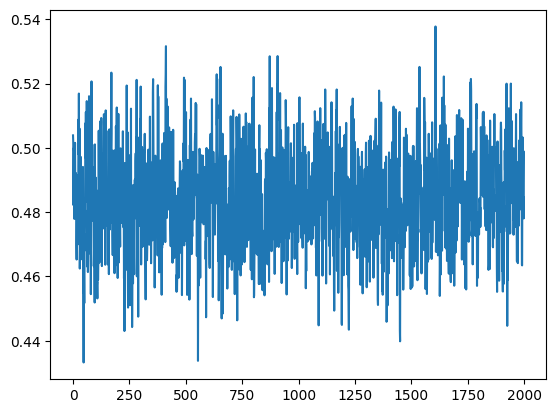

In [17]:
plt.plot(fit.lengthscale_geo)

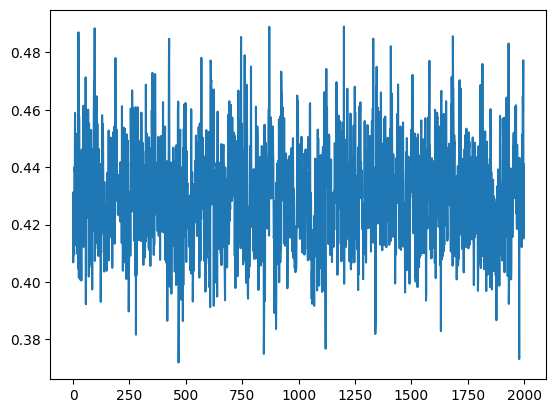

In [20]:
plt.plot(fit.sigma_geo)

In [18]:
import pickle

with open("geographical_scale_alignment_hrater_23_apr_2025.pkl","wb") as file:
    pickle.dump(fit, file)

## Posterior sample analysis

In [163]:
## Load new jersey sampled dataset for comparison
with open('annual_seasonality_nj2.pkl', 'rb') as file:
    fit_as_nj = pickle.load(file)

In [19]:
with open("geographical_scale_alignment_hrater_23_apr_2025.pkl","rb") as file:
    fit = pickle.load(file)

EOFError: Ran out of input

Could not find entry kenblue in list of entries, showing results for Kenblue instead


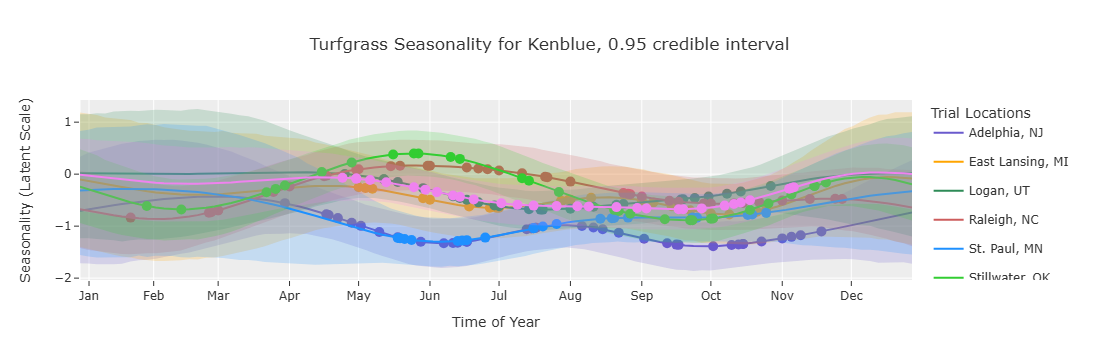

In [161]:
compare_seasonality_curve_by_locs(entry_str = 'kenblue',
                        df=df,
                        fit=fit,
                        entry_name2code=entry_name2code,
                        testloc_code2name=testloc_code2name,
                        loc_codes = [1,2,3,4,5,6,7],
                        colors =  ['slateblue','orange','seagreen', 'indianred', 'dodgerblue', 'limegreen', 'violet', 'gold', 'aquamarine', 'crimson'],
                        ci = 0.95,
                        pred_N = 100)

Could not find entry skye in list of entries, showing results for Skye instead


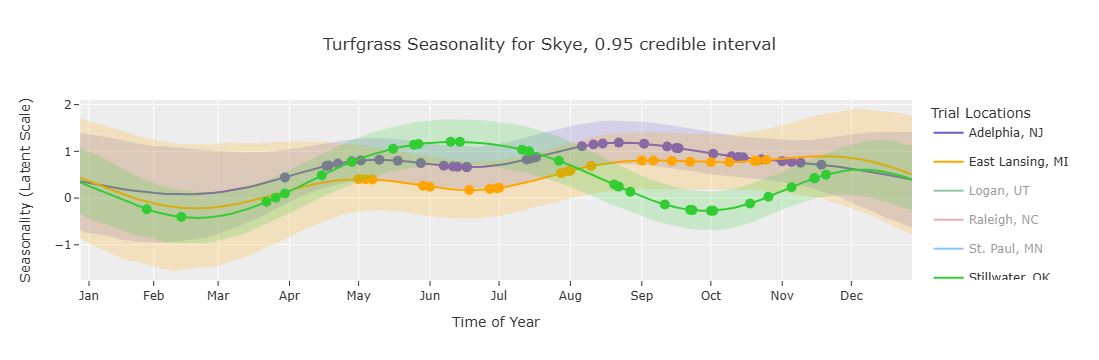

In [162]:
compare_seasonality_curve_by_locs(entry_str = 'skye',
                        df=df,
                        fit=fit,
                        entry_name2code=entry_name2code,
                        testloc_code2name=testloc_code2name,
                        loc_codes = [1,2,3,4,5,6,7],
                        colors =  ['slateblue','orange','seagreen', 'indianred', 'dodgerblue', 'limegreen', 'violet', 'gold', 'aquamarine', 'crimson'],
                        ci = 0.95,
                        pred_N = 100)

Could not find entry kenblue in list of entries, showing results for Kenblue instead
Could not find entry selway in list of entries, showing results for Selway instead
Could not find entry skye in list of entries, showing results for Skye instead
Could not find entry pivot in list of entries, showing results for Pivot instead
Could not find entry blue devil in list of entries, showing results for Blue Devil instead


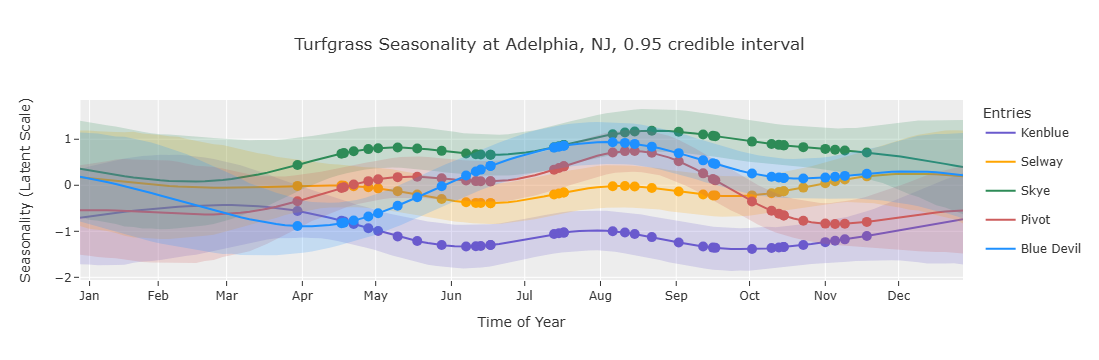

In [157]:
plot_entries_at_loc(entry_strs = ['kenblue', 'selway', 'skye', 'pivot', 'blue devil'],
                        df = df,
                        fit = fit,
                        entry_name2code = entry_name2code,
                        testloc_code2name = testloc_code2name,
                        loc_code = 1,
                        ci = 0.95,
                        pred_N = 100)

Could not find entry kenblue in list of entries, showing results for Kenblue instead
Could not find entry selway in list of entries, showing results for Selway instead
Could not find entry skye in list of entries, showing results for Skye instead
Could not find entry pivot in list of entries, showing results for Pivot instead
Could not find entry blue devil in list of entries, showing results for Blue Devil instead


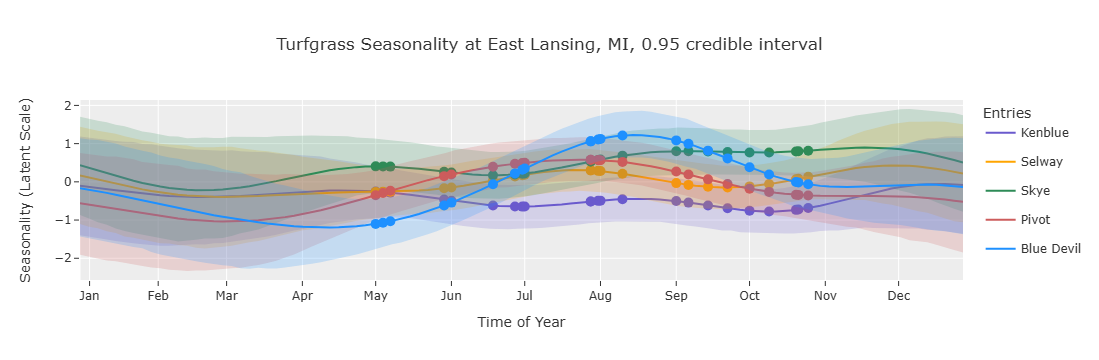

In [158]:
plot_entries_at_loc(entry_strs = ['kenblue', 'selway', 'skye', 'pivot', 'blue devil'],
                        df = df,
                        fit = fit,
                        entry_name2code = entry_name2code,
                        testloc_code2name = testloc_code2name,
                        loc_code = 2,
                        ci = 0.95,
                        pred_N = 100)

Could not find entry blue devil in list of entries, showing results for Blue Devil instead


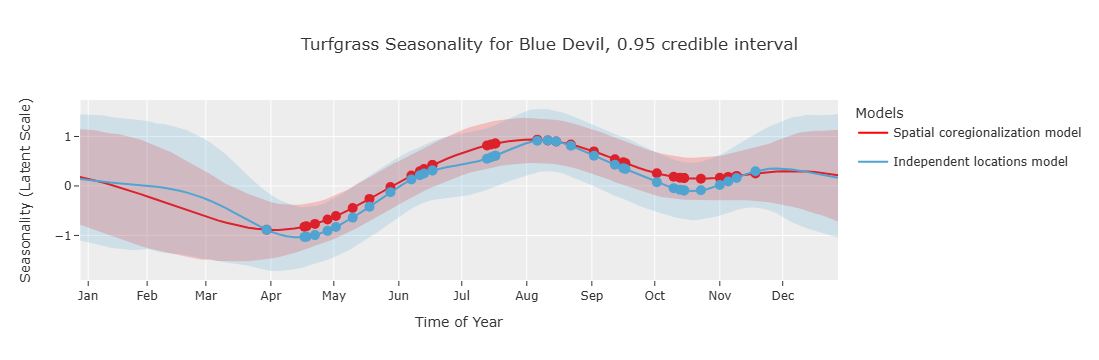

In [170]:
compare_seasonality_with_annual_model(entry_str = 'blue devil', 
                                      df = df, 
                                      fit_geo = fit, 
                                      fit_as = fit_as_nj,
                                      geo_entry_name2code = entry_name2code,
                                      as_entry_name2code = entry_name2code,
                                      loc_code = 1,
                                      colors=["red", "#4fa3d1", "orange", "#2b7b93"],
                                      ci = 0.95)

In [180]:
import sys

total_size = 0
for var in fit.stan_variables().keys():
    arr = fit.stan_variable(var)
    var_size = sys.getsizeof(arr)
    print(f"Variable: {var}, Size: {var_size} bytes")
    total_size += var_size

print(f"Total size: {total_size} bytes")

Variable: sigma_plot, Size: 128 bytes
Variable: z, Size: 160 bytes
Variable: lengthscale_plot, Size: 128 bytes
Variable: lengthscale_f, Size: 112 bytes
Variable: sigma_f, Size: 112 bytes
Variable: lengthscale_geo, Size: 112 bytes
Variable: sigma_geo, Size: 112 bytes
Variable: z_geo, Size: 128 bytes
Variable: z_intercept, Size: 144 bytes
Variable: z_beta, Size: 160 bytes
Variable: beta_rater_population_mean, Size: 128 bytes
Variable: beta_rater_population_var, Size: 112 bytes
Variable: beta_rater, Size: 144 bytes
Variable: plot_effect_loc, Size: 144 bytes
Variable: plot_effect, Size: 128 bytes
Variable: time_effect, Size: 160 bytes
Variable: intercept_f, Size: 144 bytes
Variable: beta_f, Size: 160 bytes
Variable: diagSPD_f, Size: 144 bytes
Variable: geo_cov, Size: 144 bytes
Variable: L_cov, Size: 144 bytes
Variable: log_lik, Size: 128 bytes
Total size: 2976 bytes


In [183]:
import sys

total_size = 0
for var in fit_as.stan_variables().keys():
    arr = fit_as.stan_variable(var)
    var_size = sys.getsizeof(arr)
    print(f"Variable: {var}, Size: {var_size} bytes")
    total_size += var_size

print(f"Total size: {total_size} bytes")

Variable: sigma_plot, Size: 112 bytes
Variable: z, Size: 144 bytes
Variable: lengthscale_plot, Size: 112 bytes
Variable: intercept_f, Size: 128 bytes
Variable: beta_f, Size: 144 bytes
Variable: lengthscale_f, Size: 112 bytes
Variable: sigma_f, Size: 112 bytes
Variable: tau_rater, Size: 144 bytes
Variable: plot_effect, Size: 128 bytes
Variable: time_effect, Size: 144 bytes
Variable: diagSPD_f, Size: 128 bytes
Variable: PHI_f, Size: 144 bytes
Variable: rfft2_cov, Size: 144 bytes
Variable: f, Size: 144 bytes
Variable: pred_time_effect, Size: 144 bytes
Variable: pred_PHI_f, Size: 144 bytes
Variable: log_lik, Size: 128 bytes
Total size: 2256 bytes


In [184]:
fit_as.pred_time_effect.shape

(6000, 89, 100)

In [185]:
fit_as.tau_rater.shape

(6000, 7, 8)

In [23]:
(diagSPD_periodic(1, 1, 8) * fit.beta_f[0,0,:,0]).shape

(16,)

In [24]:
rc = plot_reconstructed_curve(58, 1, pred_N= 50, max_samples = 2000)

In [256]:
rc[i].shape

(51,)

In [255]:
fit.pred_time_effect[i,0,57,:].shape

(50,)

In [218]:
fit.pred_time_effect.shape

(2000, 4, 89, 50)

In [ ]:
plot_reconstructed_curve[1:]

In [55]:
extract_beta_f(58, 1).shape

(2000, 16)

In [176]:
colors = ['royalblue', 'mediumseagreen', 'deepskyblue', 'crimson']

entries = [i for i in range(len(entry_code2name))]

entries_str = ['Kenblue', 'Skye', 'Selway', 'Pivot']
entries = [entry_name2code[w] for w in entries_str]

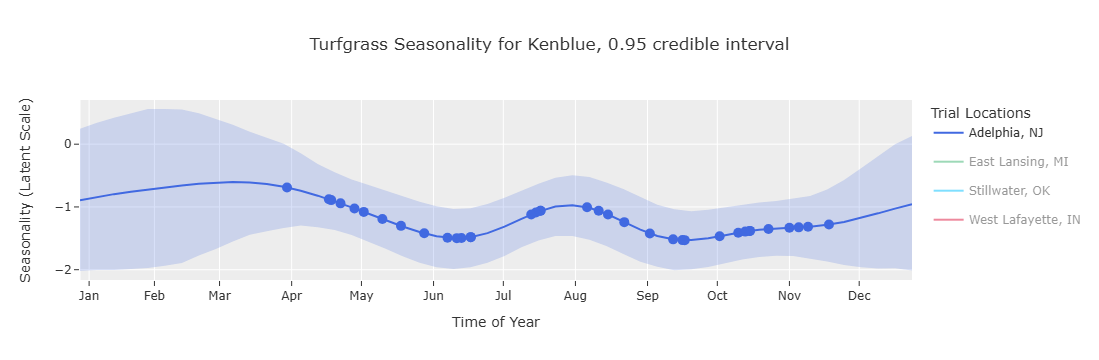

In [225]:
compare_seasonality_curve_by_locs([1,2,3,4,], 58, colors, df, 0.95)

In [96]:
fit.pred_time_effect.shape

(2000, 4, 89, 50)

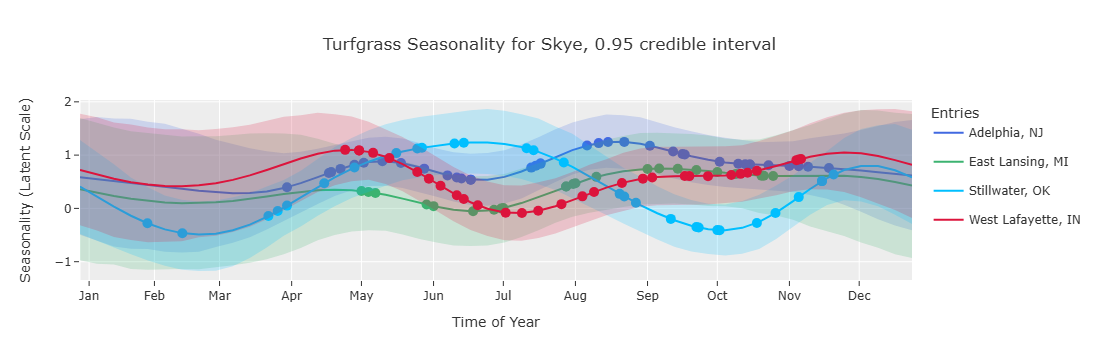

In [180]:
compare_seasonality_curve_by_locs([1,2,3,4,], 84, colors, df, 0.95)

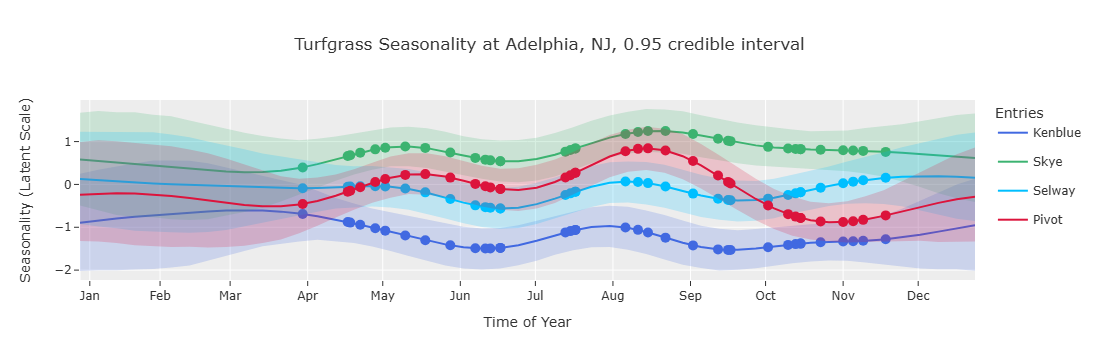

In [177]:
plot_seasonality_curve(1, entries, colors, df, 0.95)

In [150]:
df_entry = df[df['entry_name'] == 'Babe']
df_entry.groupby('test_loc')['quality'].mean()

test_loc
Adelphia, NJ          4.379630
East Lansing, MI      6.072464
Stillwater, OK        5.133333
West Lafayette, IN    5.400000
Name: quality, dtype: float64

In [153]:
df_entry = df[df['entry_name'] == 'Selway']
df_entry.groupby('test_loc')['quality'].mean()

test_loc
Adelphia, NJ          4.666667
East Lansing, MI      5.927536
Stillwater, OK        5.322222
West Lafayette, IN    5.588889
Name: quality, dtype: float64

In [152]:
df_entry = df[df['entry_name'] == 'Pivot']
df_entry.groupby('test_loc')['quality'].mean()

test_loc
Adelphia, NJ          4.685185
East Lansing, MI      5.666667
Stillwater, OK        4.322222
West Lafayette, IN    5.222222
Name: quality, dtype: float64

In [154]:
df_entry = df[df['entry_name'] == 'Blue Devil']
df_entry.groupby('test_loc')['quality'].mean()

test_loc
Adelphia, NJ          5.101852
East Lansing, MI      6.405797
Stillwater, OK        5.311111
West Lafayette, IN    5.577778
Name: quality, dtype: float64

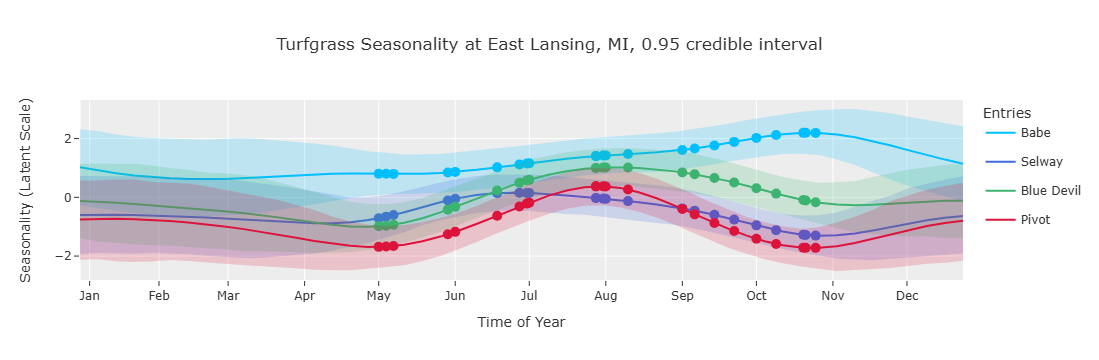

In [127]:
plot_seasonality_curve(2, entries, colors, df, 0.95)

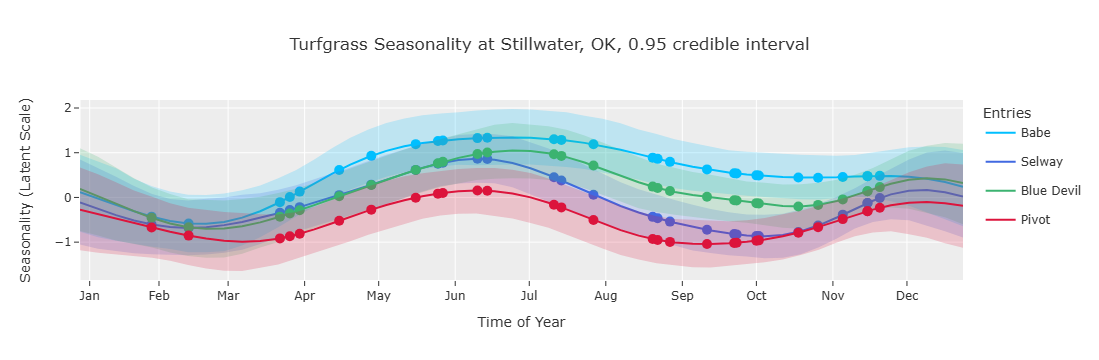

In [126]:
plot_seasonality_curve(3, entries, colors, df, 0.95)

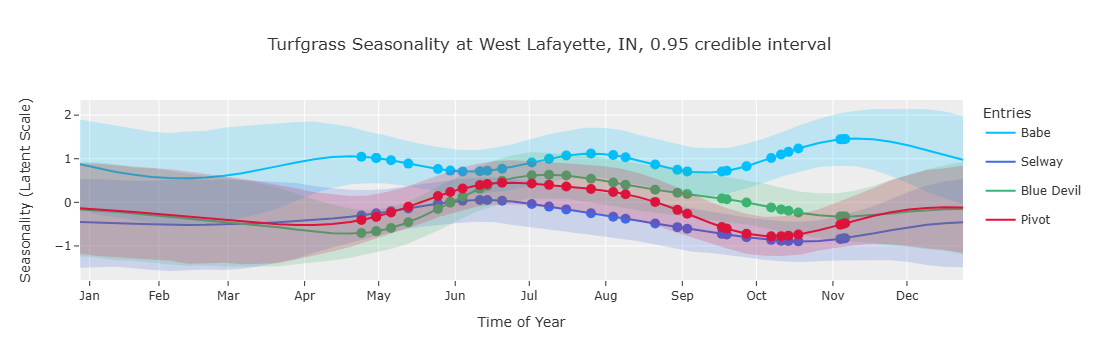

In [128]:
plot_seasonality_curve(4, entries, colors, df, 0.95)

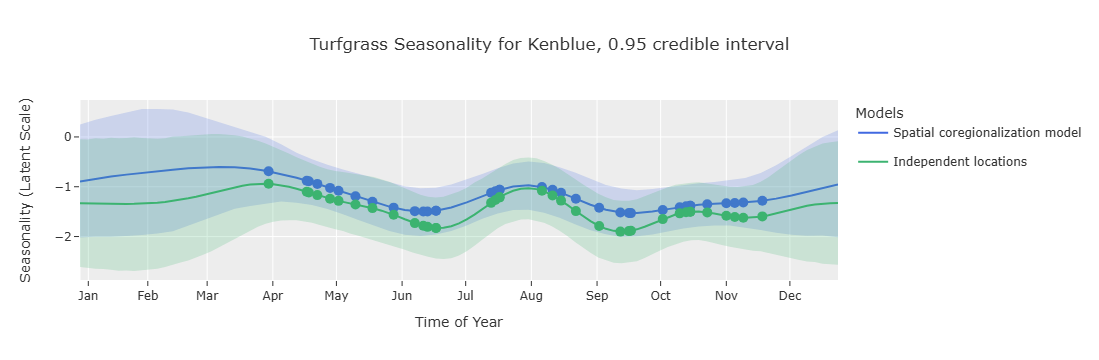

In [222]:
compare_seasonality_with_annual_model(58, colors, df)

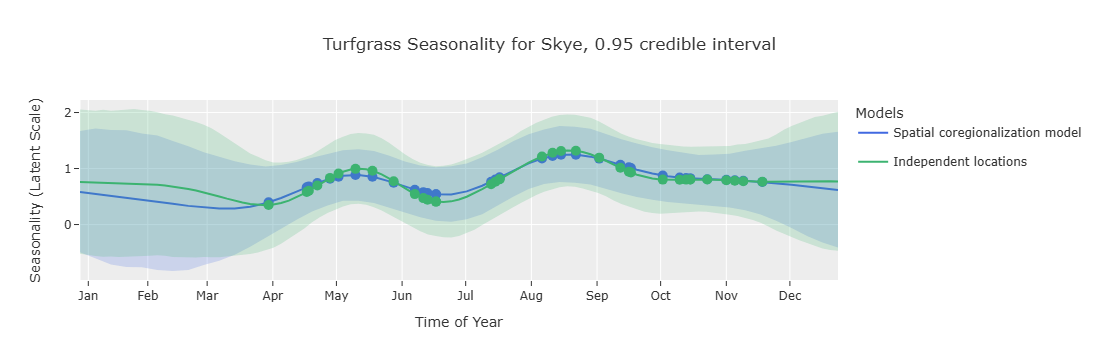

In [237]:
compare_seasonality_with_annual_model(84, colors, df)

In [236]:
entries

[58, 84, 82, 78]

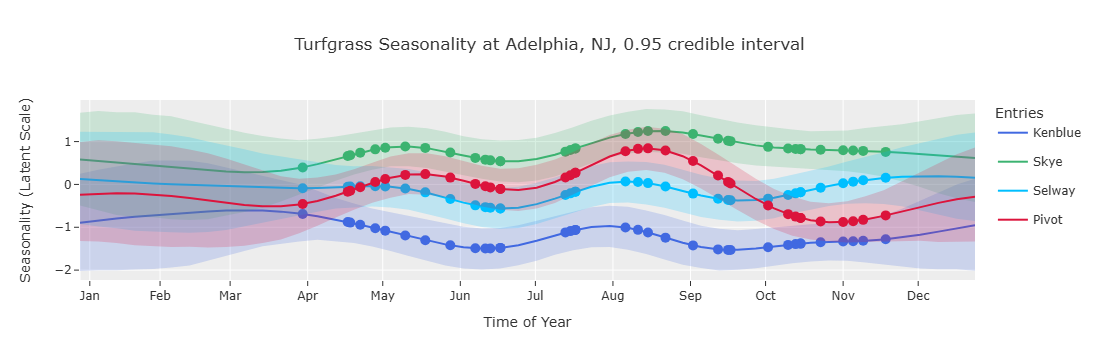

In [202]:
plot_seasonality_curve(1, entries, colors, df, 0.95)

In [239]:
entries

[58, 84, 82, 78]

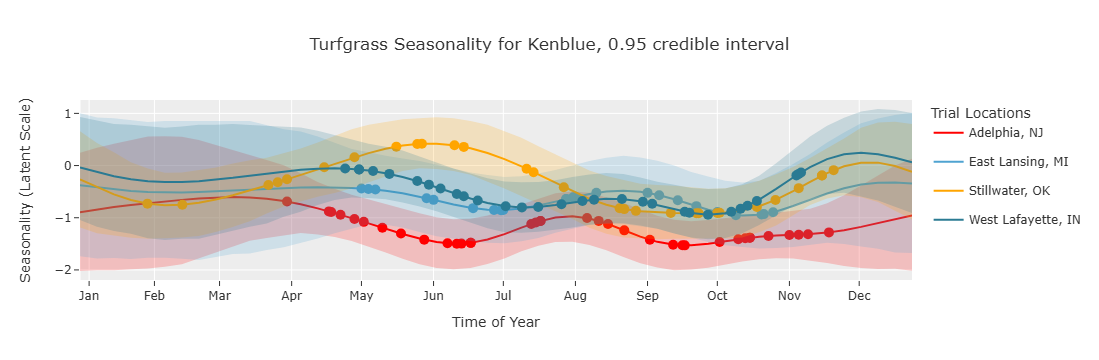

In [235]:
compare_seasonality_curve_by_locs([1,2,3,4,], 58, ["red", "#4fa3d1", "orange", "#2b7b93"], df, 0.95)

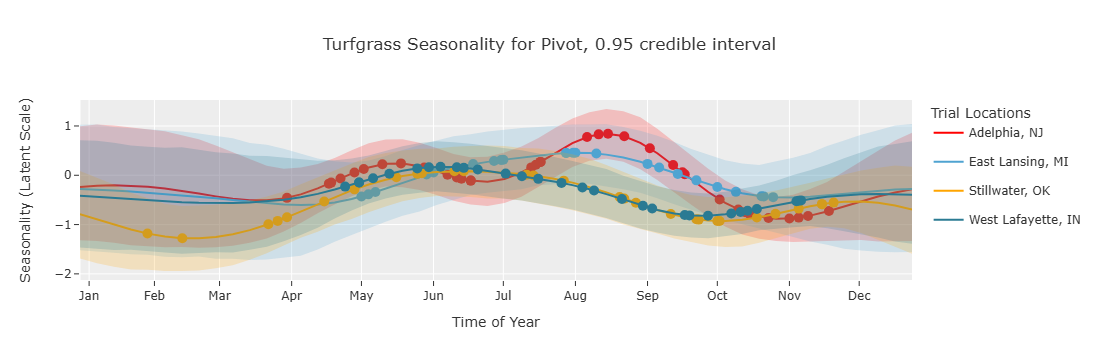

In [241]:
compare_seasonality_curve_by_locs([1,2,3,4,], 78, ["red", "#4fa3d1", "orange", "#2b7b93"], df, 0.95)

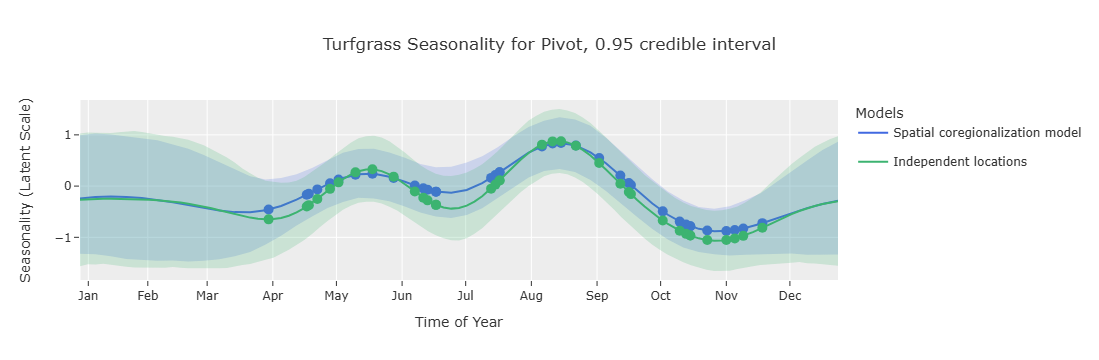

In [243]:
compare_seasonality_with_annual_model(78, colors, df)

In [266]:
entry_name2code['Blue Devil']

29

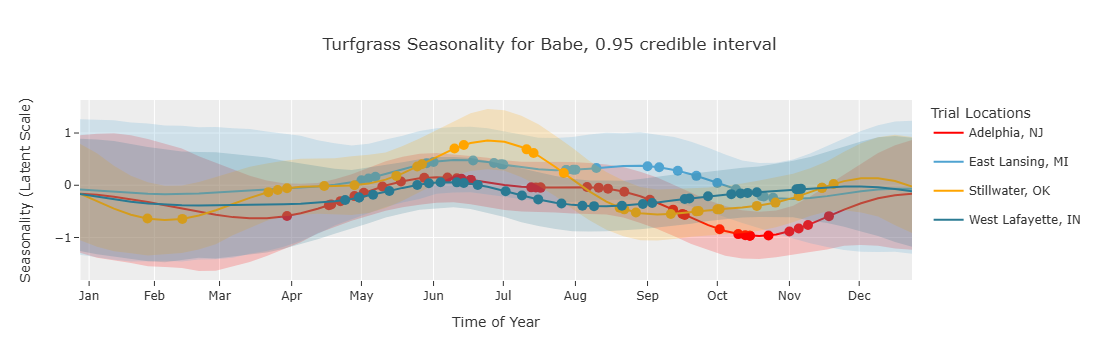

In [260]:
compare_seasonality_curve_by_locs([1,2,3,4,], 26, ["red", "#4fa3d1", "orange", "#2b7b93"], df, 0.95)

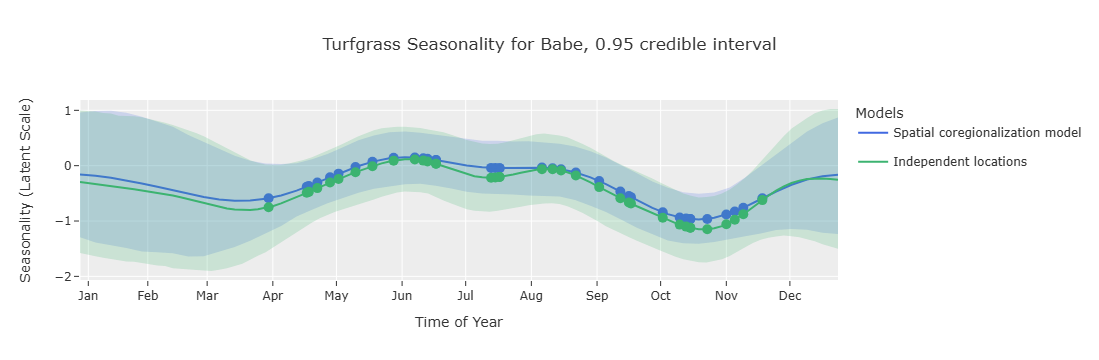

In [261]:
compare_seasonality_with_annual_model(26, colors, df)

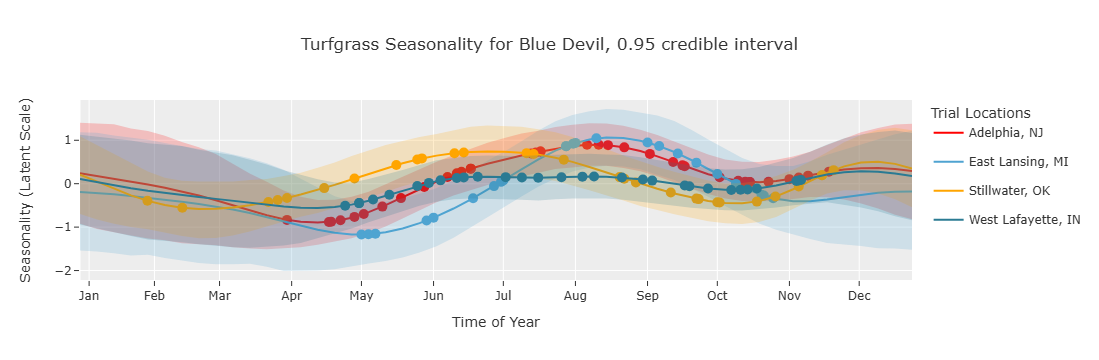

In [267]:
compare_seasonality_curve_by_locs([1,2,3,4,], 29, ["red", "#4fa3d1", "orange", "#2b7b93"], df, 0.95)

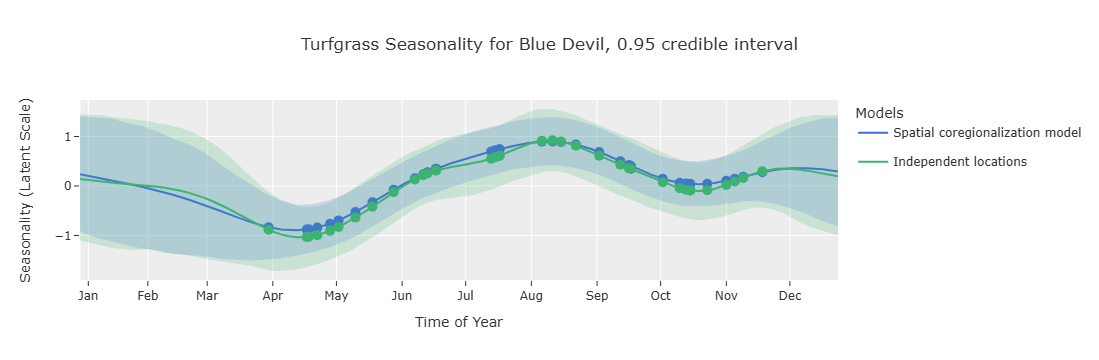

In [268]:
compare_seasonality_with_annual_model(29, colors, df)